In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from selenium import webdriver
from selenium.webdriver.common.by import By

# --- Setup ---
driver = webdriver.Chrome()
driver.get("https://liv.ac.uk/library/#")  # replace with your URL

# Storage
times = []
percent1 = []
percent2 = []

start_time = time.time()
duration = 5  # seconds
interval = 1   # seconds between samples

# --- Data collection loop ---
while time.time() - start_time < duration:
    current_time = time.time() - start_time

    try:
        # Replace with actual selectors from your page
        elems = driver.find_elements(By.CLASS_NAME, "rb-card__title mt-rb--spacing--s")

        values = []
        for e in elems:
            text = e.text.replace('%', '').strip()
            if text:
                values.append(float(text))

        # Handle missing data cases
        if len(values) == 2:
            p1, p2 = values
        elif len(values) == 1:
            p1, p2 = values[0], np.nan
        else:
            p1, p2 = np.nan, np.nan

    except Exception:
        p1, p2 = np.nan, np.nan

    # Store data
    times.append(current_time)
    percent1.append(p1)
    percent2.append(p2)

    print(f"t={current_time:.1f}s | p1={p1} | p2={p2}")

    time.sleep(interval)

driver.quit()

t=0.0s | p1=nan | p2=nan
t=1.0s | p1=nan | p2=nan
t=2.0s | p1=nan | p2=nan
t=3.0s | p1=nan | p2=nan
t=4.0s | p1=nan | p2=nan


In [5]:
import requests
print(requests.get("https://liv.ac.uk/library/#").text)


<!doctype html>
<html lang="en-GB">

<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>
    Library | University of Liverpool  </title>

  <link rel="stylesheet" href="https://www.liverpool.ac.uk/rb/latest/assets/redbrick.css" />

  <!-- Google Tag Manager -->
  <script>
    (function(w, d, s, l, i) {
      w[l] = w[l] || [];
      w[l].push({
        'gtm.start': new Date().getTime(),
        event: 'gtm.js'
      });
      var f = d.getElementsByTagName(s)[0],
        j = d.createElement(s),
        dl = l != 'dataLayer' ? '&l=' + l : '';
      j.async = true;
      j.src =
        'https://www.googletagmanager.com/gtm.js?id=' + i + dl;
      f.parentNode.insertBefore(j, f);
    })(window, document, 'script', 'dataLayer', 'GTM-WNRD24SK');
  </script>
  <!-- End Google Tag Manager -->

  <meta name="publisher" content="University of Liverpool" />
  <meta name="copyright" content="University of Liverpool" />
  <meta n

In [6]:
import requests
print(requests.get("https://libraryoccupancyapi.liverpool.ac.uk/occupancy").text)

[{"zoneNo":"Sydney Jones Library","currentOccupancy":5,"maxOccupancy":1545,"zoneID":1},{"zoneNo":"Harold Cohen Library","currentOccupancy":237,"maxOccupancy":1208,"zoneID":2}]


In [7]:
import requests

url = "https://libraryoccupancyapi.liverpool.ac.uk/occupancy"

data = requests.get(url).json()

print(data)

[{'zoneNo': 'Sydney Jones Library', 'currentOccupancy': 5, 'maxOccupancy': 1545, 'zoneID': 1}, {'zoneNo': 'Harold Cohen Library', 'currentOccupancy': 237, 'maxOccupancy': 1208, 'zoneID': 2}]


In [8]:
p1 = data[0]["currentOccupancy"]
p2 = data[1]["currentOccupancy"]

In [10]:
import time
import requests
import numpy as np
import matplotlib.pyplot as plt

url = "https://libraryoccupancyapi.liverpool.ac.uk/occupancy"

times = []
occ1 = []
occ2 = []

start_time = time.time()
duration = 10      # seconds
interval = 2       # seconds

while time.time() - start_time < duration:
    t = time.time() - start_time

    try:
        data = requests.get(url).json()

        # Extract safely
        if len(data) >= 2:
            p1 = data[0]["currentOccupancy"]
            p2 = data[1]["currentOccupancy"]
        elif len(data) == 1:
            p1 = data[0]["currentOccupancy"]
            p2 = np.nan
        else:
            p1, p2 = np.nan, np.nan

    except Exception:
        p1, p2 = np.nan, np.nan

    times.append(t)
    occ1.append(p1)
    occ2.append(p2)

    print(f"t={t:.1f}s | SJ={p1} | HC={p2}")

    time.sleep(interval)

t=0.0s | SJ=5 | HC=237
t=2.3s | SJ=5 | HC=237
t=4.5s | SJ=5 | HC=237
t=6.8s | SJ=5 | HC=237
t=9.1s | SJ=5 | HC=237


In [ ]:
times = np.array(times)
occ1 = np.array(occ1)
occ2 = np.array(occ2)

plt.plot(times, occ1, label="Sydney Jones")
plt.plot(times, occ2, label="Harold Cohen")

plt.xlabel("Time (s)")
plt.ylabel("Occupancy")
plt.legend()
plt.show()

t=0.0s | SJ=3 | HC=219


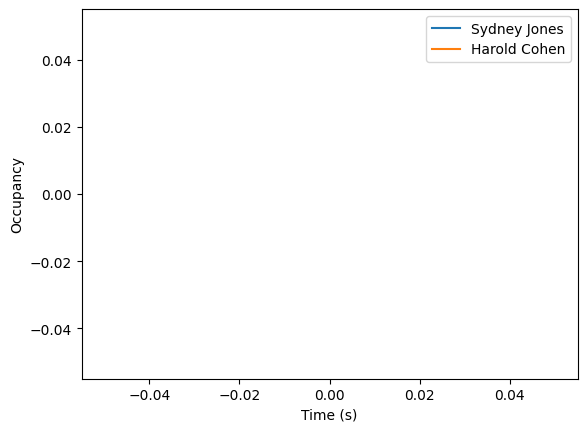

t=2.5s | SJ=3 | HC=219
t=4.8s | SJ=3 | HC=219
t=7.2s | SJ=3 | HC=219
t=9.6s | SJ=3 | HC=219


In [13]:
import time
import requests
import numpy as np
import matplotlib.pyplot as plt

# --- SETTINGS ---
url = "https://libraryoccupancyapi.liverpool.ac.uk/occupancy"

duration = 10       # seconds (set to None for infinite)
interval = 2        # seconds (use 60 or 300 for real use)

SAVE_DATA = True
SAVE_FILE = "occupancy.npy"
SAVE_EVERY = 5      # save every N samples

ROLLING_WINDOW = None   # number of points to display (None = show all)

# --- STORAGE ---
times = []
occ1 = []
occ2 = []

# --- LIVE PLOT SETUP ---
plt.ion()
fig, ax = plt.subplots()

line1, = ax.plot([], [], label="Sydney Jones")
line2, = ax.plot([], [], label="Harold Cohen")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Occupancy")
ax.legend()

start_time = time.time()
iteration = 0

# --- LOOP ---
while True:
    t = time.time() - start_time

    # Stop condition (for testing)
    if duration is not None and t > duration:
        break

    try:
        data = requests.get(url).json()

        zones = {z["zoneNo"]: z for z in data}

        sj = zones.get("Sydney Jones Library", {})
        hc = zones.get("Harold Cohen Library", {})

        p1 = sj.get("currentOccupancy", np.nan)
        p2 = hc.get("currentOccupancy", np.nan)

    except Exception:
        p1, p2 = np.nan, np.nan

    # Store
    times.append(t)
    occ1.append(p1)
    occ2.append(p2)

    iteration += 1
    print(f"t={t:.1f}s | SJ={p1} | HC={p2}")

    # --- LIVE PLOT ---
    line1, = ax.plot([], [], marker='o', label="Sydney Jones")
    line2, = ax.plot([], [], marker='o', label="Harold Cohen")

    ax.relim()
    ax.autoscale_view()

    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.pause(0.1)

    # --- OPTIONAL SAVE ---
    if SAVE_DATA and iteration % SAVE_EVERY == 0:
        np.save(SAVE_FILE, np.column_stack((times, occ1, occ2)))

    time.sleep(interval)

# Final save (just in case)
if SAVE_DATA:
    np.save(SAVE_FILE, np.column_stack((times, occ1, occ2)))

plt.ioff()
plt.show()

In [12]:
print(times[-5:], occ1[-5:], occ2[-5:])

[0.0, 2.423231363296509, 4.812613248825073, 7.191899061203003, 9.561104774475098] [3, 3, 3, 3, 3] [221, 220, 220, 220, 220]
